In [2]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.stats import moment
import matplotlib.colors as mcolors
from matplotlib.ticker import MultipleLocator, AutoMinorLocator


import cartopy.crs as ccrs
import cartopy.feature as cfeature



import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns

from pylab import rcParams
rcParams['axes.labelweight'] = 'normal'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'normal'

In [3]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds

In [4]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp)
ocean_mask = masks.seamask

# SST

In [5]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(time = slice('1979', '2023'))

#aso only
sst = sst.where(sst.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

#ocean only
sst = sst.where(ocean_mask)


In [6]:
fp = '/data/jmex/NOAA//latest/precip.mon.mean.nc'
tp = xr.open_dataset(fp)
tp = tp.drop_vars(['time_bnds', 'lat_bnds', 'lon_bnds']).rename({'precip':'tp'})
#interpolated ocean mask
ocean_mask_interp = ocean_mask.interp(lat = tp.lat, lon= tp.lon, method = 'linear')
#aso mean
tp= tp.where(tp.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

#ocean only
tp = tp.where(ocean_mask_interp)

In [7]:
# compute anomalies
tp_clim = tp.sel(year = slice(1991, 2020)).mean('year')
tp = tp - tp_clim

# compute anomalies
sst_clim = sst.sel(year = slice(1991, 2020)).mean('year')
sst = sst - sst_clim

In [8]:
# make 2023 and composite events
composite_years = [1982, 1987, 1991, 1997, 2015]

#tp
tp_2023 = tp.sel(year = 2023)
tp_composite_all = tp.where(tp.year.isin(composite_years), drop = True)
tp_composite = tp_composite_all.mean('year')
tp_diff = tp_2023 - tp_composite

#sst
sst_2023 = sst.sel(year = 2023)
sst_composite_all = sst.where(sst.year.isin(composite_years), drop = True)
sst_composite = sst_composite_all.mean('year')
sst_diff = sst_2023 - sst_composite

## Plotting

/tmp/ipykernel_2915500/2652740316.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_2915500/2652740316.py:77: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


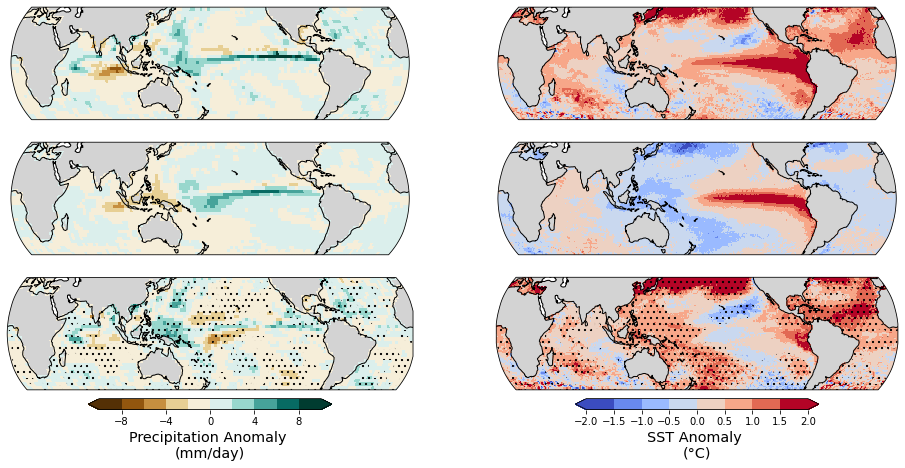

In [9]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import get_cmap

# Define projection
projection = ccrs.Robinson(central_longitude=180)

# Discrete colormap settings
tp_bounds = np.arange(-10, 12, 2)
sst_bounds = np.arange(-2, 2.5, 0.5)
tp_cmap = get_cmap('BrBG', len(tp_bounds)-1)
sst_cmap = get_cmap('coolwarm', len(sst_bounds)-1)
tp_norm = BoundaryNorm(tp_bounds, tp_cmap.N)
sst_norm = BoundaryNorm(sst_bounds, sst_cmap.N)

# Create figure and subplots (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(16, 8), subplot_kw={'projection': projection})

# Row labels
tp_datasets = [tp_2023, tp_composite, tp_diff]
sst_datasets = [sst_2023, sst_composite, sst_diff]



for row in range(3):
    # Left column: TP
    ax_tp = axes[row, 0]
    data_tp = tp_datasets[row].sel(lat = slice(-45, 45))
    img_tp = ax_tp.pcolormesh(data_tp.lon, data_tp.lat, data_tp.tp, cmap=tp_cmap, norm=tp_norm,
                              transform=ccrs.PlateCarree(), shading='auto')
    ax_tp.coastlines()
    ax_tp.add_feature(cfeature.LAND, zorder=0, facecolor='lightgray')
    ax_tp.set_xticks([])
    ax_tp.set_yticks([])

    # Right column: SST
    ax_sst = axes[row, 1]
    data_sst = sst_datasets[row].sel(lat = slice(45, -45))
    img_sst = ax_sst.pcolormesh(data_sst.lon, data_sst.lat, data_sst.sst, cmap=sst_cmap, norm=sst_norm,
                                transform=ccrs.PlateCarree(), shading='auto')
    ax_sst.coastlines()
    ax_sst.add_feature(cfeature.LAND, zorder=0, facecolor='lightgray')
    ax_sst.set_xticks([])
    ax_sst.set_yticks([])

# Add one colorbar for TP (left column)
cbar_tp = fig.colorbar(img_tp, ax=axes[:, 0], orientation='horizontal', fraction=0.1, pad=0.02, shrink=0.6, extend='both')
cbar_tp.set_label('Precipitation Anomaly \n(mm/day)')

# Add one colorbar for SST (right column)
cbar_sst = fig.colorbar(img_sst, ax=axes[:, 1], orientation='horizontal', fraction=0.1, pad=0.02, shrink=0.6, extend='both')
cbar_sst.set_label('SST Anomaly \n(°C)')

# Add hatching for significance on TP diff (row 2, left)
larger_tp = tp_2023.tp > tp_composite_all.tp
smaller_tp = tp_2023.tp < tp_composite_all.tp
sig_tp = larger_tp.all(dim='year') | smaller_tp.all(dim='year')
sig_tp = sig_tp.sel(lat = slice(-45, 45))


axes[2, 0].contourf(sig_tp.lon, sig_tp.lat, sig_tp, levels=[0.5, 1.5],
                    hatches=['..'], colors='none', transform=ccrs.PlateCarree())

# Add hatching for significance on SST diff (row 2, right)
larger_sst = sst_2023.sst > sst_composite_all.sst
smaller_sst = sst_2023.sst < sst_composite_all.sst
sig_sst = larger_sst.all(dim='year') | smaller_sst.all(dim='year')
sig_sst = sig_sst.sel(lat = slice(45, -45))

axes[2, 1].contourf(sig_sst.lon, sig_sst.lat, sig_sst, levels=[0.5, 1.5],
                    hatches=['..'], colors='none', transform=ccrs.PlateCarree())

# Layout
plt.tight_layout()
fig.savefig('output/FigS5.pdf', bbox_inches = 'tight')
